<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/260427_Bayesian_Test_EAGLE_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q gwosc healpy astropy scipy requests

In [9]:
# Robust GW190814 metadata + skymap download
# If needed:
# !pip install -q gwosc healpy astropy scipy requests beautifulsoup4

from gwosc.api import fetch_event_json
import requests
from bs4 import BeautifulSoup
import re

EVENT = "GW190814"

event_json = fetch_event_json(EVENT)
event_data = event_json["events"][0] if isinstance(event_json.get("events"), list) else list(event_json["events"].values())[0]

print("GWOSC summary parameters:")
for k in [
    "commonName",
    "catalog.shortName",
    "GPS",
    "luminosity_distance",
    "luminosity_distance_lower",
    "luminosity_distance_upper",
    "luminosity_distance_unit",
    "redshift",
    "redshift_lower",
    "redshift_upper",
    "network_matched_filter_snr",
]:
    print(f"{k}: {event_data.get(k)}")

# Pull the detailed event JSON if available
detail = {}
jsonurl = event_data.get("jsonurl")
if jsonurl:
    r = requests.get(jsonurl, timeout=60)
    r.raise_for_status()
    detail = r.json()
    print("\nFetched detailed JSON:", jsonurl)

# Search both summary and detail JSON text for FITS links
combined_text = str(event_data) + "\n" + str(detail)
fits_links = re.findall(r"https?://[^\s'\"<>]+?\.fits(?:\.gz)?", combined_text)

skymap_url = None
for url in fits_links:
    if "skymap" in url.lower():
        skymap_url = url
        break

# If GWOSC detail still does not expose the skymap, parse the official DCC document page.
if skymap_url is None:
    dcc_page = "https://dcc.ligo.org/LIGO-P2000230/public"
    html = requests.get(dcc_page, timeout=60).text
    soup = BeautifulSoup(html, "html.parser")

    candidate_links = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        text = a.get_text(" ", strip=True)
        if "GW190814_skymap" in href or "GW190814_skymap" in text:
            candidate_links.append(requests.compat.urljoin(dcc_page, href))

    print("\nCandidate DCC skymap links:")
    for link in candidate_links:
        print(link)

    # Prefer standard HEALPix FITS.GZ over multiorder for this workflow
    for link in candidate_links:
        low = link.lower()
        if low.endswith(".fits.gz") and "multiorder" not in low:
            skymap_url = link
            break

    if skymap_url is None and candidate_links:
        skymap_url = candidate_links[0]

if skymap_url is None:
    raise RuntimeError("Could not find a GW190814 skymap URL.")

print("\nUsing skymap URL:")
print(skymap_url)

local_file = f"{EVENT}_skymap.fits.gz"
r = requests.get(skymap_url, timeout=60)
r.raise_for_status()

with open(local_file, "wb") as f:
    f.write(r.content)

print("\nDownloaded:", local_file)
print("Bytes:", len(r.content))

GWOSC summary parameters:
commonName: GW190814
catalog.shortName: GWTC-2.1-confident
GPS: 1249852257.0
luminosity_distance: 230.0
luminosity_distance_lower: -50.0
luminosity_distance_upper: 40.0
luminosity_distance_unit: Mpc
redshift: 0.05
redshift_lower: -0.01
redshift_upper: 0.01
network_matched_filter_snr: 25.3

Fetched detailed JSON: https://gwosc.org/eventapi/json/GWTC-2.1-confident/GW190814/v3

Candidate DCC skymap links:
https://dcc.ligo.org/public/0169/P2000230/005/GW190814_skymap.fits.gz
https://dcc.ligo.org/public/0169/P2000230/005/GW190814_skymap.multiorder.fits

Using skymap URL:
https://dcc.ligo.org/public/0169/P2000230/005/GW190814_skymap.fits.gz

Downloaded: GW190814_skymap.fits.gz
Bytes: 1472321


In [10]:
# GW190814: download skymap + compute 90% sky area and distance interval
# Run this in a fresh notebook cell.

# If needed, uncomment this first line:
# !pip install -q gwosc healpy astropy scipy requests beautifulsoup4

from gwosc.api import fetch_event_json
import requests
from bs4 import BeautifulSoup
import re
import numpy as np
import healpy as hp
from astropy.io import fits
from scipy.integrate import cumulative_trapezoid

EVENT = "GW190814"
CREDIBLE_LEVEL = 0.90

# ------------------------------------------------------------
# 1. Fetch GWOSC event metadata
# ------------------------------------------------------------

event_json = fetch_event_json(EVENT)

if isinstance(event_json.get("events"), list):
    event_data = event_json["events"][0]
else:
    event_data = list(event_json["events"].values())[0]

print("GWOSC summary parameters")
print("------------------------")
for k in [
    "commonName",
    "catalog.shortName",
    "GPS",
    "luminosity_distance",
    "luminosity_distance_lower",
    "luminosity_distance_upper",
    "luminosity_distance_unit",
    "redshift",
    "redshift_lower",
    "redshift_upper",
    "network_matched_filter_snr",
]:
    print(f"{k}: {event_data.get(k)}")

d_med_gwosc = event_data["luminosity_distance"]
d_low_gwosc = d_med_gwosc + event_data["luminosity_distance_lower"]
d_high_gwosc = d_med_gwosc + event_data["luminosity_distance_upper"]

print("\nGWOSC quoted luminosity-distance interval:")
print(f"{d_med_gwosc:.1f} Mpc, range {d_low_gwosc:.1f}–{d_high_gwosc:.1f} Mpc")

# ------------------------------------------------------------
# 2. Find and download GW190814 skymap
# ------------------------------------------------------------

detail = {}
jsonurl = event_data.get("jsonurl")

if jsonurl:
    r = requests.get(jsonurl, timeout=60)
    r.raise_for_status()
    detail = r.json()

combined_text = str(event_data) + "\n" + str(detail)
fits_links = re.findall(r"https?://[^\s'\"<>]+?\.fits(?:\.gz)?", combined_text)

skymap_url = None

for url in fits_links:
    if "skymap" in url.lower():
        skymap_url = url
        break

# If GWOSC metadata does not expose the skymap, parse the official DCC public page
if skymap_url is None:
    dcc_page = "https://dcc.ligo.org/LIGO-P2000230/public"
    html = requests.get(dcc_page, timeout=60).text
    soup = BeautifulSoup(html, "html.parser")

    candidate_links = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        text = a.get_text(" ", strip=True)
        if "GW190814_skymap" in href or "GW190814_skymap" in text:
            candidate_links.append(requests.compat.urljoin(dcc_page, href))

    print("\nCandidate DCC skymap links:")
    for link in candidate_links:
        print(link)

    for link in candidate_links:
        low = link.lower()
        if low.endswith(".fits.gz") and "multiorder" not in low:
            skymap_url = link
            break

    if skymap_url is None and candidate_links:
        skymap_url = candidate_links[0]

if skymap_url is None:
    raise RuntimeError("Could not find a GW190814 skymap URL.")

print("\nUsing skymap URL:")
print(skymap_url)

local_file = f"{EVENT}_skymap.fits.gz"
r = requests.get(skymap_url, timeout=60)
r.raise_for_status()

with open(local_file, "wb") as f:
    f.write(r.content)

print("\nDownloaded:", local_file)
print("Bytes:", len(r.content))

# ------------------------------------------------------------
# 3. Read HEALPix skymap
# ------------------------------------------------------------

with fits.open(local_file, memmap=True) as hdul:
    data = hdul[1].data
    header = hdul[1].header

    prob = np.asarray(data["PROB"], dtype=float)
    distmu = np.asarray(data["DISTMU"], dtype=float)
    distsigma = np.asarray(data["DISTSIGMA"], dtype=float)
    distnorm = np.asarray(data["DISTNORM"], dtype=float) if "DISTNORM" in data.names else None

    nside = int(header["NSIDE"])
    ordering = header.get("ORDERING", "NESTED").upper()
    nest = ordering.startswith("NEST")

print("\nSkymap metadata")
print("---------------")
print(f"NSIDE: {nside}")
print(f"ORDERING: {ordering}")
print(f"Number of pixels: {len(prob):,}")
print(f"Total probability in map: {prob.sum():.8f}")

# ------------------------------------------------------------
# 4. Compute 90% credible sky area
# ------------------------------------------------------------

def credible_region_mask(probability, credible_level=0.90):
    order = np.argsort(probability)[::-1]
    cumulative = np.cumsum(probability[order])
    cutoff_index = np.searchsorted(cumulative, credible_level)
    selected = order[:cutoff_index + 1]

    mask = np.zeros_like(probability, dtype=bool)
    mask[selected] = True

    return mask, selected, cumulative[cutoff_index]

mask90, pix90, enclosed_prob90 = credible_region_mask(prob, CREDIBLE_LEVEL)

pixel_area_sr = hp.nside2pixarea(nside)
pixel_area_deg2 = hp.nside2pixarea(nside, degrees=True)

sky_area_90_deg2 = mask90.sum() * pixel_area_deg2
sky_area_90_sr = mask90.sum() * pixel_area_sr

print("\nSky localisation")
print("----------------")
print(f"{CREDIBLE_LEVEL:.0%} credible sky area: {sky_area_90_deg2:.3f} deg²")
print(f"{CREDIBLE_LEVEL:.0%} credible sky area: {sky_area_90_sr:.6e} sr")
print(f"Probability enclosed by selected pixels: {enclosed_prob90:.6f}")

theta, phi = hp.pix2ang(nside, pix90, nest=nest)
ra90 = np.degrees(phi) % 360
dec90 = 90 - np.degrees(theta)

print("\nApproximate bounding box of selected 90% pixels:")
print(f"RA range:  {ra90.min():.4f} to {ra90.max():.4f} deg")
print(f"Dec range: {dec90.min():.4f} to {dec90.max():.4f} deg")

# ------------------------------------------------------------
# 5. Compute marginal luminosity-distance posterior from 3D skymap
# ------------------------------------------------------------

def distance_pdf_grid(prob, distmu, distsigma, distnorm=None, r_grid=None):
    valid = (
        np.isfinite(prob) &
        np.isfinite(distmu) &
        np.isfinite(distsigma) &
        (prob > 0) &
        (distsigma > 0)
    )

    p = prob[valid]
    mu = distmu[valid]
    sig = distsigma[valid]

    if distnorm is not None:
        dn = distnorm[valid]
    else:
        dn = 1.0 / (np.sqrt(2 * np.pi) * sig)

    if r_grid is None:
        r_min = max(0.0, np.nanmin(mu - 6 * sig))
        r_max = np.nanmax(mu + 6 * sig)
        r_grid = np.linspace(r_min, r_max, 5000)

    pdf = np.zeros_like(r_grid, dtype=float)

    chunk = 4096
    for start in range(0, len(p), chunk):
        stop = start + chunk

        rr = r_grid[:, None]
        this_mu = mu[start:stop][None, :]
        this_sig = sig[start:stop][None, :]
        this_p = p[start:stop][None, :]
        this_dn = dn[start:stop][None, :]

        conditional = this_dn * rr**2 * np.exp(-0.5 * ((rr - this_mu) / this_sig)**2)
        pdf += np.sum(this_p * conditional, axis=1)

    area = np.trapz(pdf, r_grid)
    pdf /= area

    cdf = cumulative_trapezoid(pdf, r_grid, initial=0)
    cdf /= cdf[-1]

    return r_grid, pdf, cdf

r_grid, pdf_r, cdf_r = distance_pdf_grid(prob, distmu, distsigma, distnorm)

lower_q = (1 - CREDIBLE_LEVEL) / 2
upper_q = 1 - lower_q

d_lower = np.interp(lower_q, cdf_r, r_grid)
d_median = np.interp(0.50, cdf_r, r_grid)
d_upper = np.interp(upper_q, cdf_r, r_grid)

# Narrowest 90% interval on the 1D marginal distance posterior
best_width = np.inf
best_pair = None

for i in range(len(r_grid)):
    target = cdf_r[i] + CREDIBLE_LEVEL
    if target > 1:
        break

    j = np.searchsorted(cdf_r, target)

    if j < len(r_grid):
        width = r_grid[j] - r_grid[i]
        if width < best_width:
            best_width = width
            best_pair = (r_grid[i], r_grid[j])

d_hpd_lower, d_hpd_upper = best_pair

print("\nLuminosity-distance posterior from skymap")
print("-----------------------------------------")
print(f"Equal-tailed {CREDIBLE_LEVEL:.0%} distance interval: {d_lower:.1f}–{d_upper:.1f} Mpc")
print(f"Median distance: {d_median:.1f} Mpc")
print(f"Approx. narrowest {CREDIBLE_LEVEL:.0%} distance interval: {d_hpd_lower:.1f}–{d_hpd_upper:.1f} Mpc")

# ------------------------------------------------------------
# 6. Approximate top-hat comparison volume
# ------------------------------------------------------------

mock_volume_mpc3 = (sky_area_90_sr / 3.0) * (d_upper**3 - d_lower**3)

print("\nApproximate top-hat comparison volume")
print("-------------------------------------")
print(f"Using 90% sky area + equal-tailed 90% distance shell:")
print(f"{mock_volume_mpc3:,.0f} Mpc³")
print(f"{mock_volume_mpc3 / 1e9:.3e} Gpc³")

GWOSC summary parameters
------------------------
commonName: GW190814
catalog.shortName: GWTC-2.1-confident
GPS: 1249852257.0
luminosity_distance: 230.0
luminosity_distance_lower: -50.0
luminosity_distance_upper: 40.0
luminosity_distance_unit: Mpc
redshift: 0.05
redshift_lower: -0.01
redshift_upper: 0.01
network_matched_filter_snr: 25.3

GWOSC quoted luminosity-distance interval:
230.0 Mpc, range 180.0–270.0 Mpc

Candidate DCC skymap links:
https://dcc.ligo.org/public/0169/P2000230/005/GW190814_skymap.fits.gz
https://dcc.ligo.org/public/0169/P2000230/005/GW190814_skymap.multiorder.fits

Using skymap URL:
https://dcc.ligo.org/public/0169/P2000230/005/GW190814_skymap.fits.gz

Downloaded: GW190814_skymap.fits.gz
Bytes: 1472321

Skymap metadata
---------------
NSIDE: 1024
ORDERING: NESTED
Number of pixels: 12,582,912
Total probability in map: 1.00000000

Sky localisation
----------------
90% credible sky area: 18.497 deg²
90% credible sky area: 5.634583e-03 sr
Probability enclosed by sele

/tmp/ipykernel_14795/917207854.py:221: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, r_grid)


In [12]:
!pip install -q git+https://github.com/jchelly/eagleSqlTools.git

  Preparing metadata (setup.py) ... done


In [16]:
# Inspect available columns in relevant EAGLE tables

import numpy as np
import pandas as pd

for table in ["RefL0100N1504_SubHalo", "RefL0100N1504_Aperture"]:
    print(f"\n--- {table} ---")
    q = f"SELECT TOP 5 * FROM {table}"
    raw = sql.execute_query(con, q)
    df = pd.DataFrame(np.atleast_1d(raw))
    print(df.columns.tolist())
    display(df.head())


--- RefL0100N1504_SubHalo ---
['GalaxyID', 'DescendantID', 'LastProgID', 'TopLeafID', 'SnapNum', 'RandomNumber', 'Redshift', 'GroupID', 'GroupNumber', 'SubGroupNumber', 'CentreOfMass_x', 'CentreOfMass_y', 'CentreOfMass_z', 'CentreOfPotential_x', 'CentreOfPotential_y', 'CentreOfPotential_z', 'Velocity_x', 'Velocity_y', 'Velocity_z', 'BlackHoleMass', 'BlackHoleMassAccretionRate', 'GasSpin_x', 'GasSpin_y', 'GasSpin_z', 'KineticEnergy', 'ThermalEnergy', 'MechanicalEnergy', 'TotalEnergy', 'Vmax', 'VmaxRadius', 'Mass', 'MassType_BH', 'MassType_DM', 'MassType_Gas', 'MassType_Star', 'HalfMassProjRad_BH', 'HalfMassProjRad_DM', 'HalfMassProjRad_Gas', 'HalfMassProjRad_Star', 'HalfMassRad_BH', 'HalfMassRad_DM', 'HalfMassRad_Gas', 'HalfMassRad_Star', 'StarFormationRate', 'InitialMassWeightedBirthZ', 'InitialMassWeightedStellarAge', 'StellarInitialMass', 'StellarVelDisp', 'Stars_Carbon', 'Stars_Helium', 'Stars_Hydrogen', 'Stars_Iron', 'Stars_IronFromSNIa', 'Stars_KineticEnergy', 'Stars_Magnesium', 

,GalaxyID,DescendantID,LastProgID,TopLeafID,SnapNum,RandomNumber,Redshift,GroupID,GroupNumber,SubGroupNumber,...,NSF_Spin_x,NSF_Spin_y,NSF_Spin_z,NSF_ThermalEnergy,NSF_TotalEnergy,Spurious,Image_ID,Image_face,Image_edge,Image_box
0,1,1,13630,28,28,0.672620,2.220446e-16,28000000000000,1,42,...,0.0,0.0,0.0,0.0,0.0,0,1,"b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag..."
1,2,1,13630,28,27,0.095938,1.006385e-01,27000000000004,5,19,...,0.0,0.0,0.0,0.0,0.0,0,2,"b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag..."
2,3,2,13629,28,26,0.648907,1.827099e-01,26000000000004,5,15,...,0.0,0.0,0.0,0.0,0.0,0,3,"b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag..."
3,4,3,13629,28,25,0.039211,2.709011e-01,25000000000004,5,8,...,0.0,0.0,0.0,0.0,0.0,0,4,"b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag..."
4,5,4,13629,28,24,0.817048,3.656686e-01,24000000000003,4,4,...,0.0,0.0,0.0,0.0,0.0,0,5,"b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag...","b""<img src='http://virgodb.cosma.dur.ac.uk/eag..."



--- RefL0100N1504_Aperture ---
['GalaxyID', 'ApertureSize', 'Mass_BH', 'Mass_DM', 'Mass_Gas', 'Mass_Star', 'VelDisp', 'SFR']


,GalaxyID,ApertureSize,Mass_BH,Mass_DM,Mass_Gas,Mass_Star,VelDisp,SFR
0,1,1,0.0,3.005464e+08,0.0,7.718300e+09,151.777161,0.0
1,2,1,869601024.0,8.143839e+08,0.0,1.033686e+10,161.792816,0.0
2,3,1,0.0,8.919443e+08,0.0,1.198640e+10,167.999451,0.0
3,4,1,869601024.0,1.153710e+09,0.0,1.459256e+10,170.543472,0.0
4,5,1,869601024.0,1.367001e+09,0.0,1.639602e+10,168.274124,0.0


In [17]:
query = """
SELECT
    SH.GalaxyID,
    SH.GroupNumber,
    SH.SubGroupNumber,
    SH.CentreOfPotential_x AS x,
    SH.CentreOfPotential_y AS y,
    SH.CentreOfPotential_z AS z,
    AP.Mass_Star AS Mstar_30pkpc,
    AP.Mass_Gas AS Mgas_30pkpc,
    AP.SFR AS SFR_30pkpc,
    SH.StarFormationRate AS SFR_subhalo
FROM
    RefL0100N1504_SubHalo AS SH,
    RefL0100N1504_Aperture AS AP
WHERE
    SH.GalaxyID = AP.GalaxyID
    AND SH.SnapNum = 28
    AND AP.ApertureSize = 30
    AND AP.Mass_Star > 1e8
ORDER BY
    AP.Mass_Star DESC
"""

eagle = pd.DataFrame(np.atleast_1d(sql.execute_query(con, query)))

print("\nDownloaded EAGLE galaxies:")
print(eagle.shape)
display(eagle.head())


Downloaded EAGLE galaxies:
(40076, 10)


,GalaxyID,GroupNumber,SubGroupNumber,x,y,z,Mstar_30pkpc,Mgas_30pkpc,SFR_30pkpc,SFR_subhalo
0,21242350,1,1,11.369572,80.663208,54.190159,4.647067e+11,2.852355e+10,2.421584,16.287073
1,21730535,4,0,52.799755,4.919716,20.063511,4.485735e+11,2.150846e+10,2.198527,32.392792
2,21109760,1,0,17.108519,79.767769,52.717827,4.196701e+11,3.275436e+10,3.514611,10.126255
3,21986361,6,0,76.670509,89.474174,41.884659,3.729405e+11,1.981928e+10,0.851944,7.196212
4,19701409,9,0,84.921928,47.613113,7.973583,3.587923e+11,1.632664e+10,2.074490,7.807325


In [18]:
# Carve GW190814-like EAGLE subvolume and apply simple host priors

rng = np.random.default_rng(42)

# From GW190814 step
gw_volume_mpc3 = 26015
eagle_box_side_mpc = 100.0
side = gw_volume_mpc3 ** (1/3)

x0, y0, z0 = rng.uniform(0, eagle_box_side_mpc - side, size=3)
x1, y1, z1 = x0 + side, y0 + side, z0 + side

mock = eagle[
    (eagle["x"] >= x0) & (eagle["x"] < x1) &
    (eagle["y"] >= y0) & (eagle["y"] < y1) &
    (eagle["z"] >= z0) & (eagle["z"] < z1)
].copy()

print("Mock GW190814-like EAGLE volume")
print("--------------------------------")
print(f"Cube side: {side:.2f} Mpc")
print(f"x: {x0:.2f}–{x1:.2f}")
print(f"y: {y0:.2f}–{y1:.2f}")
print(f"z: {z0:.2f}–{z1:.2f}")
print(f"Galaxies selected: {len(mock)}")

def normalise_weight(values):
    arr = np.asarray(values, dtype=float)
    arr = np.where(np.isfinite(arr) & (arr > 0), arr, 0.0)
    total = arr.sum()
    return arr / total if total > 0 else np.zeros_like(arr)

# Core priors
mock["w_flat"] = 1.0 / len(mock)
mock["w_mstar"] = normalise_weight(mock["Mstar_30pkpc"])
mock["w_sfr"] = normalise_weight(mock["SFR_30pkpc"])

# Metallicity proxy from SubHalo table if present in your full pull later
# For now, if you did not include it in eagle, this will be skipped.
if "Stars_Metallicity" in mock.columns:
    Z_solar = 0.0127
    Z = np.where(mock["Stars_Metallicity"] > 0, mock["Stars_Metallicity"], np.nan)
    Z_over_Zsun = Z / Z_solar

    # Capped low-Z enhancement: exploratory, not final physics
    lowZ_factor = np.clip(Z_over_Zsun ** -1, 0, 10)

    mock["Z_over_Zsun"] = Z_over_Zsun
    mock["w_mstar_lowZ"] = normalise_weight(mock["Mstar_30pkpc"] * lowZ_factor)
    mock["w_sfr_lowZ"] = normalise_weight(mock["SFR_30pkpc"] * lowZ_factor)

prior_cols = [c for c in ["w_flat", "w_mstar", "w_sfr", "w_mstar_lowZ", "w_sfr_lowZ"] if c in mock.columns]

for col in prior_cols:
    print(f"\nTop 10 galaxies under prior: {col}")
    display(
        mock.sort_values(col, ascending=False)
        [["GalaxyID", "Mstar_30pkpc", "SFR_30pkpc", col]]
        .head(10)
    )

mock.to_csv("eagle_GW190814_like_mock_volume_priors.csv", index=False)
print("\nSaved: eagle_GW190814_like_mock_volume_priors.csv")

Mock GW190814-like EAGLE volume
--------------------------------
Cube side: 29.63 Mpc
x: 54.46–84.09
y: 30.88–60.51
z: 60.42–90.05
Galaxies selected: 904

Top 10 galaxies under prior: w_flat


,GalaxyID,Mstar_30pkpc,SFR_30pkpc,w_flat
40034,3149591,1.001801e+08,0.016684,0.001106
18,18781589,2.572008e+11,4.627411,0.001106
28,19250447,2.320766e+11,0.138327,0.001106
39,19595681,1.936739e+11,2.724785,0.001106
66,19534448,1.612636e+11,1.935585,0.001106
105,19800923,1.315134e+11,3.244844,0.001106
148,17193503,1.131447e+11,3.746344,0.001106
222,15620685,9.622375e+10,6.114940,0.001106
38676,65937584,1.069220e+08,0.000000,0.001106
38656,6729111,1.070657e+08,0.000000,0.001106



Top 10 galaxies under prior: w_mstar


,GalaxyID,Mstar_30pkpc,SFR_30pkpc,w_mstar
18,18781589,2.572008e+11,4.627411,0.062037
28,19250447,2.320766e+11,0.138327,0.055977
39,19595681,1.936739e+11,2.724785,0.046714
66,19534448,1.612636e+11,1.935585,0.038897
105,19800923,1.315134e+11,3.244844,0.031721
148,17193503,1.131447e+11,3.746344,0.027291
222,15620685,9.622375e+10,6.114940,0.023209
250,15501297,9.146577e+10,0.426028,0.022062
263,15172288,8.899104e+10,0.010035,0.021465
305,16041949,8.192648e+10,1.721645,0.019761



Top 10 galaxies under prior: w_sfr


,GalaxyID,Mstar_30pkpc,SFR_30pkpc,w_sfr
222,15620685,9.622375e+10,6.114940,0.044440
2247,18431033,1.794403e+10,4.855631,0.035288
18,18781589,2.572008e+11,4.627411,0.033630
148,17193503,1.131447e+11,3.746344,0.027226
1350,8468354,3.006650e+10,3.553464,0.025825
2098,13167235,1.931480e+10,3.378057,0.024550
541,15451066,5.860986e+10,3.267149,0.023744
2338,9076698,1.711962e+10,3.246485,0.023594
105,19800923,1.315134e+11,3.244844,0.023582
682,17379781,5.021841e+10,3.042394,0.022110



Saved: eagle_GW190814_like_mock_volume_priors.csv


In [19]:
import numpy as np

mock["logMstar"] = np.log10(mock["Mstar_30pkpc"])

print("Basic stats:")
print(mock["logMstar"].describe())

Basic stats:
count    904.000000
mean       8.823349
std        0.716347
min        8.000781
25%        8.260104
50%        8.619954
75%        9.202350
max       11.410273
Name: logMstar, dtype: float64


In [20]:
target = 369

print("\nMass cut sweep:")
for cut in np.arange(8.0, 11.5, 0.1):
    n = (mock["logMstar"] > cut).sum()
    print(f"log10(Mstar) > {cut:.1f}: {n}")


Mass cut sweep:
log10(Mstar) > 8.0: 904
log10(Mstar) > 8.1: 822
log10(Mstar) > 8.2: 720
log10(Mstar) > 8.3: 644
log10(Mstar) > 8.4: 567
log10(Mstar) > 8.5: 514
log10(Mstar) > 8.6: 468
log10(Mstar) > 8.7: 414
log10(Mstar) > 8.8: 356
log10(Mstar) > 8.9: 316
log10(Mstar) > 9.0: 294
log10(Mstar) > 9.1: 260
log10(Mstar) > 9.2: 228
log10(Mstar) > 9.3: 199
log10(Mstar) > 9.4: 175
log10(Mstar) > 9.5: 151
log10(Mstar) > 9.6: 138
log10(Mstar) > 9.7: 122
log10(Mstar) > 9.8: 110
log10(Mstar) > 9.9: 101
log10(Mstar) > 10.0: 84
log10(Mstar) > 10.1: 77
log10(Mstar) > 10.2: 59
log10(Mstar) > 10.3: 47
log10(Mstar) > 10.4: 35
log10(Mstar) > 10.5: 29
log10(Mstar) > 10.6: 22
log10(Mstar) > 10.7: 18
log10(Mstar) > 10.8: 12
log10(Mstar) > 10.9: 10
log10(Mstar) > 11.0: 6
log10(Mstar) > 11.1: 5
log10(Mstar) > 11.2: 4
log10(Mstar) > 11.3: 2
log10(Mstar) > 11.4: 1


In [21]:
cuts = np.arange(8.0, 11.5, 0.01)

best_cut = None
best_diff = np.inf

for cut in cuts:
    n = (mock["logMstar"] > cut).sum()
    diff = abs(n - target)

    if diff < best_diff:
        best_diff = diff
        best_cut = cut
        best_n = n

print(f"\nBest cut:")
print(f"log10(Mstar) > {best_cut:.2f} → {best_n} galaxies (target {target})")


Best cut:
log10(Mstar) > 8.77 → 370 galaxies (target 369)


In [22]:
mock_obs_like = mock[mock["logMstar"] > best_cut].copy()

print(f"\nFinal sample size: {len(mock_obs_like)}")


Final sample size: 370


In [23]:
def normalise_weight(values):
    arr = np.asarray(values, dtype=float)
    arr = np.where(np.isfinite(arr) & (arr > 0), arr, 0.0)
    total = arr.sum()
    return arr / total if total > 0 else np.zeros_like(arr)

mock_obs_like["w_flat"] = 1.0 / len(mock_obs_like)
mock_obs_like["w_mstar"] = normalise_weight(mock_obs_like["Mstar_30pkpc"])
mock_obs_like["w_sfr"] = normalise_weight(mock_obs_like["SFR_30pkpc"])

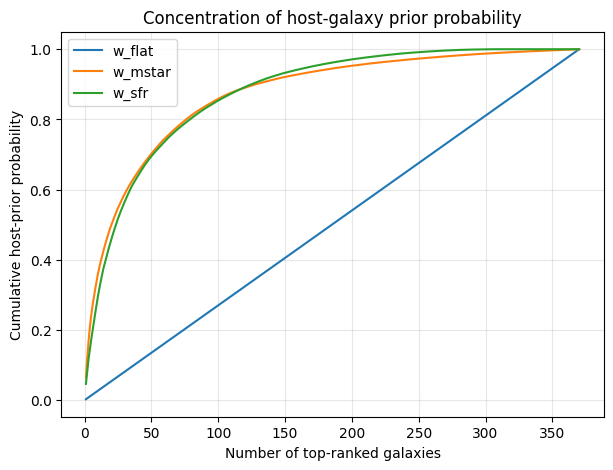

In [24]:
import matplotlib.pyplot as plt
import numpy as np

priors = ["w_flat", "w_mstar", "w_sfr"]

plt.figure(figsize=(7,5))

for col in priors:
    weights = np.sort(mock_obs_like[col].values)[::-1]
    cum = np.cumsum(weights)
    plt.plot(np.arange(1, len(cum)+1), cum, label=col)

plt.xlabel("Number of top-ranked galaxies")
plt.ylabel("Cumulative host-prior probability")
plt.title("Concentration of host-galaxy prior probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

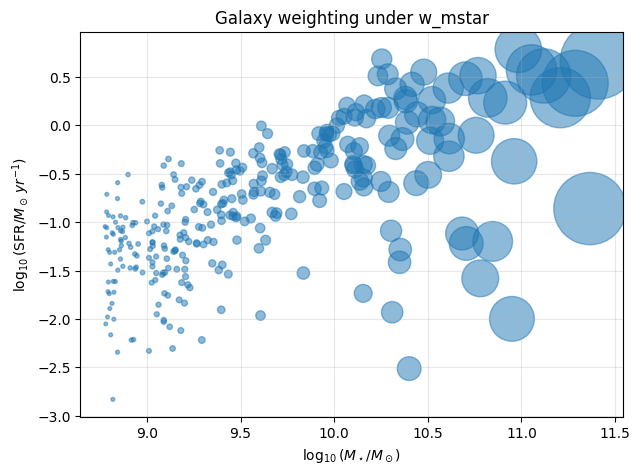

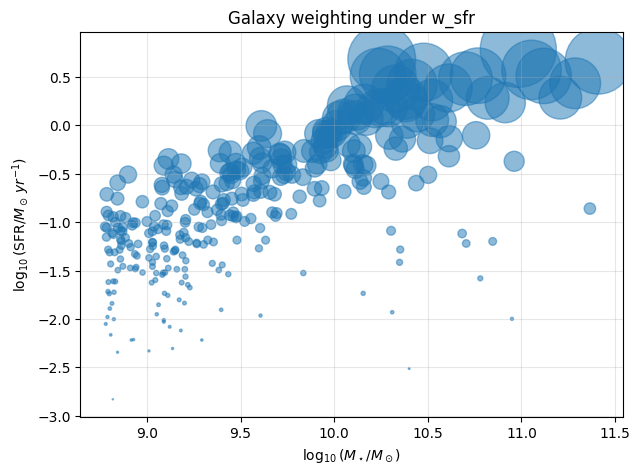

In [25]:
for col in ["w_mstar", "w_sfr"]:
    plt.figure(figsize=(7,5))

    sizes = 3000 * mock_obs_like[col] / mock_obs_like[col].max()

    plt.scatter(
        np.log10(mock_obs_like["Mstar_30pkpc"]),
        np.log10(mock_obs_like["SFR_30pkpc"].replace(0, np.nan)),
        s=sizes,
        alpha=0.5
    )

    plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    plt.ylabel(r"$\log_{10}(\mathrm{SFR}/M_\odot\,yr^{-1})$")
    plt.title(f"Galaxy weighting under {col}")
    plt.grid(alpha=0.3)
    plt.show()

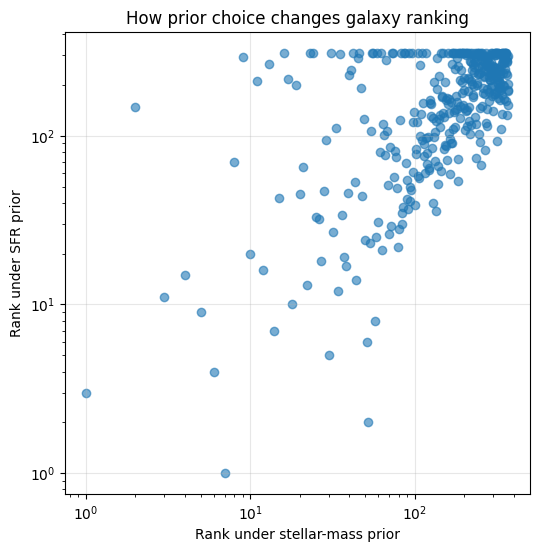

In [26]:
ranked = mock_obs_like.copy()

ranked["rank_mstar"] = ranked["w_mstar"].rank(ascending=False, method="min")
ranked["rank_sfr"] = ranked["w_sfr"].rank(ascending=False, method="min")

plt.figure(figsize=(6,6))
plt.scatter(ranked["rank_mstar"], ranked["rank_sfr"], alpha=0.6)

plt.xlabel("Rank under stellar-mass prior")
plt.ylabel("Rank under SFR prior")
plt.title("How prior choice changes galaxy ranking")
plt.xscale("log")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.show()

In [27]:
summary = []

for col in ["w_flat", "w_mstar", "w_sfr"]:
    weights = np.sort(mock_obs_like[col].values)[::-1]
    cum = np.cumsum(weights)

    n50 = np.searchsorted(cum, 0.50) + 1
    n90 = np.searchsorted(cum, 0.90) + 1
    top1 = weights[0]
    top10 = cum[9]

    summary.append({
        "prior": col,
        "top galaxy probability": top1,
        "top 10 cumulative probability": top10,
        "galaxies for 50% probability": n50,
        "galaxies for 90% probability": n90
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,prior,top galaxy probability,top 10 cumulative probability,galaxies for 50% probability,galaxies for 90% probability
0,w_flat,0.002703,0.027027,186,334
1,w_mstar,0.064099,0.360740,21,128
2,w_sfr,0.046401,0.296522,24,125
